<div style="background:linear-gradient(135deg,#042f2e 0%,#0f766e 55%,#2dd4bf 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#99f6e4;font-weight:700;text-transform:uppercase">Chapter 154 &middot; Tools &amp; Workflow &middot; Notebook 5 of 5</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Subqueries, CTEs, and the Handoff to pandas</div>
  <div style="font-size:15px;color:#ccfbf1;max-width:760px;line-height:1.6">Two tools tidy up complex SQL: subqueries nest one query inside another, and CTEs (the WITH clause) name intermediate steps so a query reads top to bottom. Then the natural division of labor: let SQL do the heavy lifting at the source, and hand a small, clean table to pandas for analysis and plots.</div>
</div>

In [1]:
import pandas as pd, sqlite3
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "sql-and-databases--shop.xlsx"
try:
    xls = pd.ExcelFile("../../data/" + fn)
except FileNotFoundError:
    xls = pd.ExcelFile(BASE + fn)
# Load the four sheets into an in-memory SQLite database, then query it with real SQL.
con = sqlite3.connect(":memory:")
for table in ["customers", "products", "orders", "order_items"]:
    pd.read_excel(xls, sheet_name=table).to_sql(table, con, index=False, if_exists="replace")

def q(sql):
    """Run a SQL query against the shop database and return the result as a DataFrame."""
    return pd.read_sql_query(sql, con)

print("tables:", [r[0] for r in con.execute("SELECT name FROM sqlite_master WHERE type='table'")])
q("SELECT * FROM products LIMIT 3")
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi':110,'axes.grid':True,'grid.alpha':0.25,'font.size':11})
TL='#0f766e'

tables: ['customers', 'products', 'orders', 'order_items']


## DEMO 1 &middot; A subquery: compare to an overall number
A subquery is a query used as a value inside another. Here the inner query computes the average customer spend, and the outer keeps only customers above it.

In [2]:
q("""WITH spend AS (
         SELECT c.customer_id, c.name, SUM(oi.revenue) AS total
         FROM order_items oi
         JOIN orders o    ON oi.order_id   = o.order_id
         JOIN customers c ON o.customer_id = c.customer_id
         GROUP BY c.customer_id)
       SELECT name, ROUND(total, 2) AS total
       FROM spend
       WHERE total > (SELECT AVG(total) FROM spend)
       ORDER BY total DESC
       LIMIT 6""")

,name,total
0,Customer 27,5495.55
1,Customer 07,5247.60
2,Customer 21,4742.40
3,Customer 34,4030.05
4,Customer 03,3990.55
5,Customer 05,3970.90


## DEMO 2 &middot; CTEs stack readably
A CTE (WITH name AS (...)) names a result you can reuse. Chaining them turns a tangled nested query into clear, ordered steps, the SQL equivalent of method chaining.

In [3]:
q("""WITH per_order AS (
         SELECT order_id, SUM(revenue) AS order_total
         FROM order_items GROUP BY order_id),
       labeled AS (
         SELECT order_id, order_total,
                CASE WHEN order_total >= 300 THEN 'large'
                     WHEN order_total >= 100 THEN 'medium'
                     ELSE 'small' END AS size_band
         FROM per_order)
       SELECT size_band, COUNT(*) AS orders, ROUND(AVG(order_total),2) AS avg_value
       FROM labeled
       GROUP BY size_band
       ORDER BY avg_value DESC""")

,size_band,orders,avg_value
0,large,101,429.23
1,medium,333,188.17
2,small,166,51.68


## DEMO 3 &middot; The handoff: SQL prepares, pandas analyzes
The professional pattern. Do the joining, filtering, and aggregating in SQL, close to the data, then read the small tidy result into a DataFrame with pandas and take it from there. read_sql_query bridges the two worlds.

In [4]:
monthly = q("""
    WITH m AS (
      SELECT strftime('%Y-%m', o.order_date) AS month, SUM(oi.revenue) AS revenue
      FROM order_items oi JOIN orders o ON oi.order_id = o.order_id
      GROUP BY month)
    SELECT month, ROUND(revenue,2) AS revenue,
           ROUND(SUM(revenue) OVER (ORDER BY month),2) AS running_total
    FROM m ORDER BY month""")
print(type(monthly).__name__, monthly.shape)
monthly.head()

DataFrame (12, 3)


,month,revenue,running_total
0,2024-01,9643.20,9643.20
1,2024-02,6706.90,16350.10
2,2024-03,11262.10,27612.20
3,2024-04,7896.30,35508.50
4,2024-05,10216.55,45725.05


## DEMO 4 &middot; Now it is just pandas: plot it
Once the data is a DataFrame, everything from the Python chapter applies. Plot the monthly revenue and the running total that SQL computed.

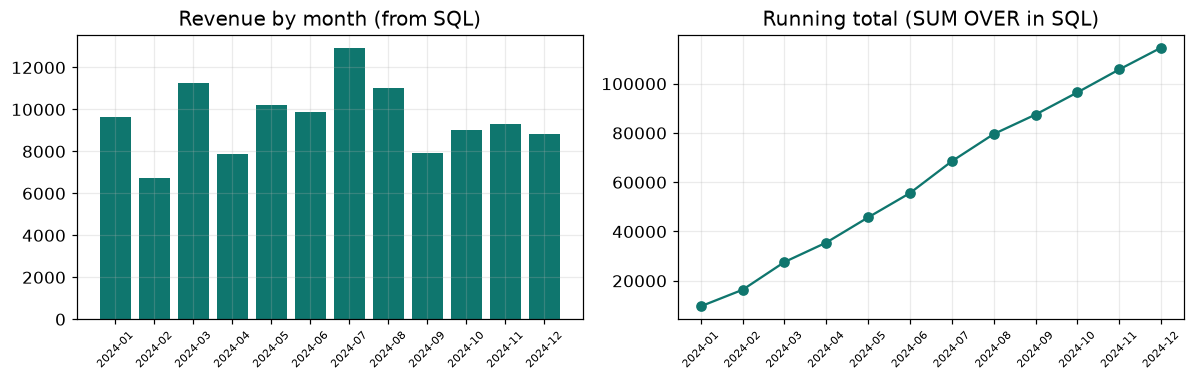

full-year revenue (running total endpoint): 114,592.40


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].bar(monthly.month, monthly.revenue, color=TL); ax[0].set_title("Revenue by month (from SQL)")
ax[0].tick_params(axis="x", rotation=45, labelsize=7)
ax[1].plot(monthly.month, monthly.running_total, marker="o", color=TL)
ax[1].set_title("Running total (SUM OVER in SQL)"); ax[1].tick_params(axis="x", rotation=45, labelsize=7)
plt.tight_layout(); plt.show()
print(f"full-year revenue (running total endpoint): {monthly.running_total.iloc[-1]:,.2f}")

### Wrap-up
Subqueries nest a query as a value; CTEs name the steps so complex logic reads in order; and the winning workflow is to push joins, filters, and aggregation into SQL where the data lives, then pull a compact result into pandas for modeling and charts. SQL and Python are not rivals here, they are a pipeline: SQL gets the data ready, Python takes it the rest of the way.